# Detekcija anomalija u financijskim transakcijama: duboki autoenkoder (PyTorch)

Ova bilježnica predstavlja samostalnu, dodatnu implementaciju dubokog autoenkodera (engl. *Autoencoder*) iste arhitekture kao u bilježnici autoencoder_keras_tensor.ipynb, ovoga puta korištenjem biblioteke PyTorch. Cilj je pokazati da je opisana arhitektura prenosiva između različitih okvira za duboko učenje, a ne proširiti službenu usporedbu modela u poglavlju 4.6. završnog rada. Rezultati ove bilježnice stoga se ne koriste u usporedbi algoritama niti u prototipu sustava, koji se u potpunosti oslanjaju na Keras/TensorFlow implementaciju.

Podatkovni skup dijeli se kronološki, identično kao u isolation_forest.ipynb i autoencoder_keras_tensor.ipynb: skup za učenje (63 %), validacijski skup (7 %) i testni skup (30 %). Prag odlučivanja određuje se na validacijskom skupu.

Datoteke amount_scaler_if.pkl i time_scaler_if.pkl iz isolation_forest.ipynb potrebno je učitati u runtime ove bilježnice (ćelija u nastavku otvara sučelje za učitavanje datoteka).

In [2]:
!pip install -q kagglehub scikit-learn pandas matplotlib seaborn joblib torch

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Koristi se uređaj: {device}")

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

Koristi se uređaj: cpu


## 1. Učitavanje podataka

In [3]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")
print(df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Predobrada i podjela podataka

Kao i kod algoritma izolacijskih stabala, kronološka podjela na tri skupa, potom RobustScaler prilagođen isključivo na skupu za učenje (*Time* i *Amount*).
Ovdje učitavamo prilagođene *Time_scaled* i *Amount_scaled* iz bilježnice isolation_forest.ipynb.

Ključna razlika: trening skup sadrži isključivo legitimne transakcije (Class = 0), u skladu s polunadziranim pristupom (autoenkoder uči rekonstruirati samo normalno ponašanje), pa transakcije koje ne uspije vjerno rekonstruirati tretiramo kao potencijalne anomalije.

Unutar skupa za učenje dodatno se izdvaja mali dio legitimnih transakcija (10 %) isključivo za potrebe ranog zaustavljanja tijekom treniranja (engl. *early stopping*). Ovo je odvojeno od službenog validacijskog skupa (7 % cjelokupnog skupa), koji se koristi za određivanje praga odlučivanja, ne za samo treniranje.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving amount_scaler_if.pkl to amount_scaler_if.pkl
Saving time_scaler_if.pkl to time_scaler_if.pkl


In [5]:
amount_scaler = joblib.load('amount_scaler_if.pkl')
time_scaler = joblib.load('time_scaler_if.pkl')
print("Both scalers uploaded successfully.")

Both scalers uploaded successfully.


In [6]:
n = len(df)
train_end = int(n * 0.63)
val_end = int(n * 0.70)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

train_df['Amount_scaled'] = amount_scaler.transform(train_df[['Amount']])
val_df['Amount_scaled'] = amount_scaler.transform(val_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

train_df['Time_scaled'] = time_scaler.transform(train_df[['Time']])
val_df['Time_scaled'] = time_scaler.transform(val_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

# train only on legitimate transactions
X_train_normal = train_df[train_df['Class'] == 0][feature_cols].values.astype(np.float32)

earlystop_split = int(len(X_train_normal) * 0.9)
X_fit = X_train_normal[:earlystop_split]
X_earlystop = X_train_normal[earlystop_split:]

X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df['Class'].values

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['Class'].values

print(f"Train (just legitimate): {X_fit.shape}")
print(f"Early stopping (just legitimate): {X_earlystop.shape}")
print(f"Validation (both classes): {X_val.shape}, Fraud Rate: {y_val.mean() * 100:.4f} %")
print(f"Test (both classes): {X_test.shape}, Fraud Rate: {y_test.mean() * 100:.4f} %")

Train (just legitimate): (161157, 30)
Early stopping (just legitimate): (17907, 30)
Validation (both classes): (19936, 30), Fraud Rate: 0.1003 %
Test (both classes): (85443, 30), Fraud Rate: 0.1264 %


## 3. Dataset i DataLoader

PyTorch zahtijeva eksplicitnu definiciju razreda skupa podataka i učitavača (engl. *data loader*), za razliku od Keras-a gdje model.fit() prihvaća NumPy nizove izravno.

In [7]:
class TransactionDataset(Dataset):
    def __init__(self, data):
        self.data = torch.from_numpy(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_loader = DataLoader(TransactionDataset(X_fit), batch_size=256, shuffle=True)
earlystop_loader = DataLoader(TransactionDataset(X_earlystop), batch_size=256, shuffle=False)

## 4. Arhitektura autoenkodera

Simetrična arhitektura enkoder – usko grlo – dekoder. Ulazna dimenzija odgovara broju značajki (30: V1–V28, Amount_scaled, Time_scaled).

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 8), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 14), nn.ReLU(),
            nn.Linear(14, 20), nn.ReLU(),
            nn.Linear(20, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

input_dim = X_fit.shape[1]
model = Autoencoder(input_dim).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=30, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=14, bias=True)
    (3): ReLU()
    (4): Linear(in_features=14, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=14, bias=True)
    (1): ReLU()
    (2): Linear(in_features=14, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=30, bias=True)
  )
)


## 5. Treniranje

Ručno implementirana petlja treniranja s ranim zaustavljanjem (engl. *early stopping*) prema gubitku na izdvojenom dijelu skupa za učenje (u Kerasu ovo obavlja callbacks.EarlyStopping, u PyTorchu se piše
eksplicitno).

Epoch 1/50 - train: 0.874005 - validation: 0.858246
Epoch 2/50 - train: 0.544209 - validation: 0.684177
Epoch 3/50 - train: 0.464607 - validation: 0.624690
Epoch 4/50 - train: 0.412768 - validation: 0.559102
Epoch 5/50 - train: 0.386608 - validation: 0.545222
Epoch 6/50 - train: 0.373751 - validation: 0.527878
Epoch 7/50 - train: 0.362242 - validation: 0.514539
Epoch 8/50 - train: 0.353113 - validation: 0.500483
Epoch 9/50 - train: 0.343668 - validation: 0.495955
Epoch 10/50 - train: 0.333400 - validation: 0.490254
Epoch 11/50 - train: 0.322842 - validation: 0.489623
Epoch 12/50 - train: 0.316800 - validation: 0.481699
Epoch 13/50 - train: 0.310570 - validation: 0.484344
Epoch 14/50 - train: 0.307297 - validation: 0.480890
Epoch 15/50 - train: 0.301808 - validation: 0.473823
Epoch 16/50 - train: 0.298008 - validation: 0.476571
Epoch 17/50 - train: 0.295217 - validation: 0.475879
Epoch 18/50 - train: 0.292835 - validation: 0.471781
Epoch 19/50 - train: 0.290971 - validation: 0.477524
Ep

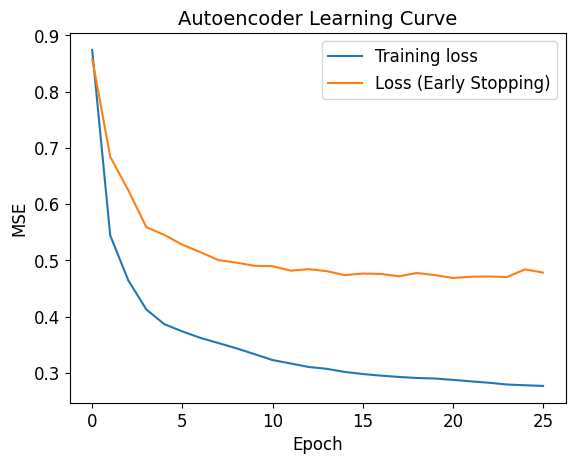

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

n_epochs = 50
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None

train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    epoch_train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction = model(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in earlystop_loader:
            batch = batch.to(device)
            reconstruction = model(batch)
            loss = criterion(reconstruction, batch)
            epoch_val_loss += loss.item() * batch.size(0)
    epoch_val_loss /= len(earlystop_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch + 1}/{n_epochs} - train: {epoch_train_loss:.6f} - validation: {epoch_val_loss:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping after epoch {epoch + 1}.")
            break

model.load_state_dict(best_state)

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Loss (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Autoencoder Learning Curve')
plt.legend()
plt.show()

## 6. Određivanje praga

Prag se određuje na temelju 99. percentila pogreške rekonstrukcije legitimnih transakcija u validacijskom skupu (7 %).

In [11]:
model.eval()
X_val_normal = X_val[y_val == 0]
with torch.no_grad():
    X_val_normal_tensor = torch.from_numpy(X_val_normal).to(device)
    X_val_normal_pred = model(X_val_normal_tensor).cpu().numpy()

val_normal_error = np.mean(np.square(X_val_normal - X_val_normal_pred), axis=1)

threshold = np.percentile(val_normal_error, 99)
print(f"Threshold (99. percentil, validation): {threshold:.4f}")

Threshold (99. percentil, validation): 2.0889


## 7. Evaluacija praga na validacijskom skupu

In [12]:
model.eval()
with torch.no_grad():
    X_val_tensor = torch.from_numpy(X_val).to(device)
    X_val_pred = model(X_val_tensor).cpu().numpy()

reconstruction_error = np.mean(np.square(X_val - X_val_pred), axis=1)
y_val_pred = (reconstruction_error > threshold).astype(int)

precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, reconstruction_error)
pr_auc = average_precision_score(y_val, reconstruction_error)

print("Results (validation):")
print(f"Precision: {precision_val:.4f}")
print(f"Recall: {recall_val:.4f}")
print(f"F1-score: {f1_val:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

Results (validation):
Precision: 0.0610
Recall: 0.6500
F1-score: 0.1116
ROC-AUC: 0.9694
PR-AUC: 0.0633


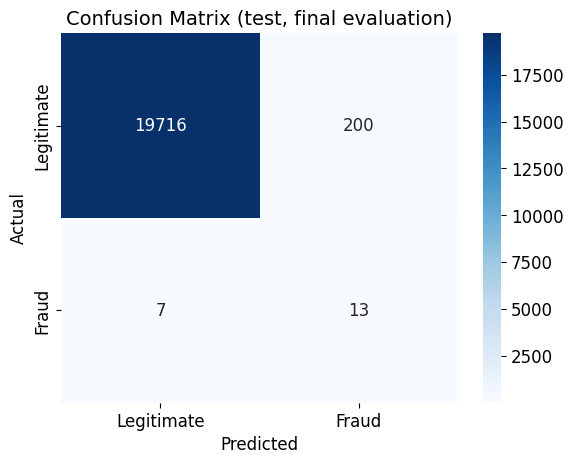

In [13]:
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix (test, final evaluation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

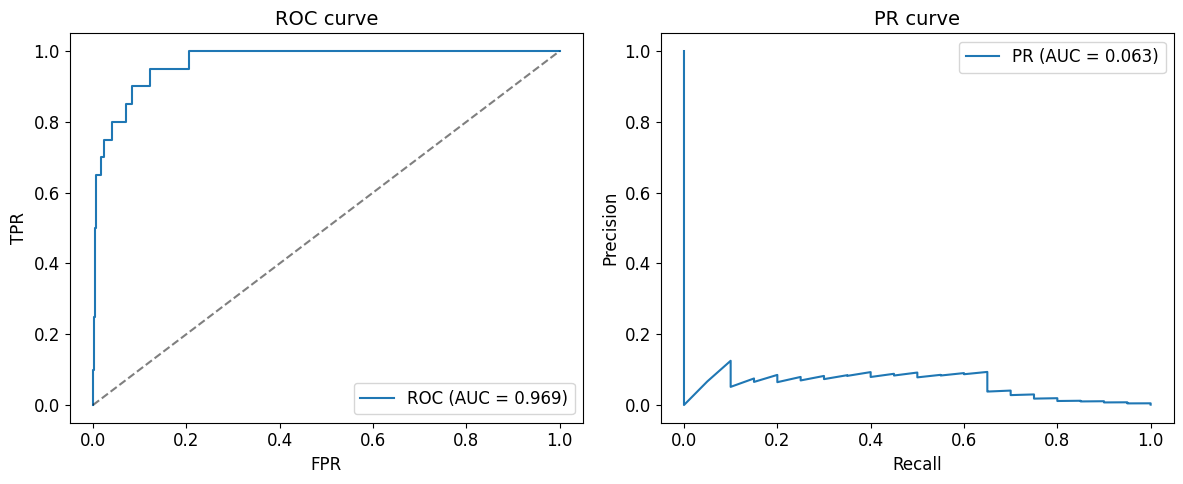

In [14]:
fpr, tpr, _ = roc_curve(y_val, reconstruction_error)
prec_curve, rec_curve, _ = precision_recall_curve(y_val, reconstruction_error)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curve')
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label=f'PR (AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curve')
axes[1].legend()
plt.tight_layout()
plt.show()

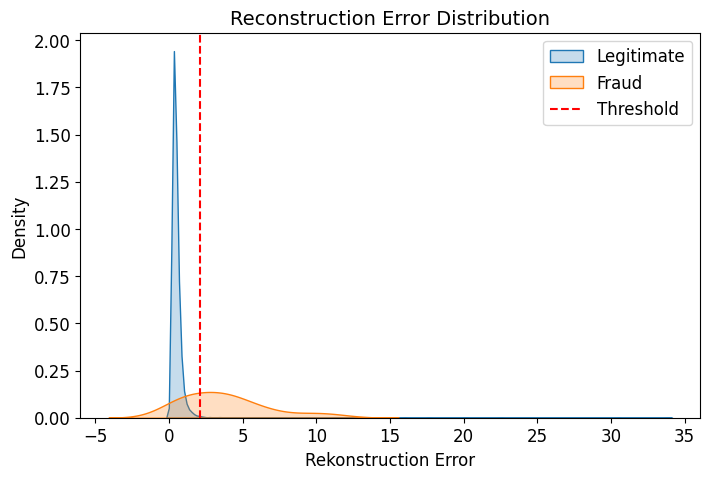

In [15]:
plt.figure(figsize=(8, 5))
sns.kdeplot(reconstruction_error[y_val == 0], label='Legitimate', fill=True)
sns.kdeplot(reconstruction_error[y_val == 1], label='Fraud', fill=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Rekonstruction Error')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.show()

## 8. Vizualizacija naučene reprezentacije (2D usko grlo)

Kako bismo intuitivno prikazali što autoenkoder uči, treniramo zaseban, ilustrativni autoenkoder s uskim grlom veličine samo 2 neurona (za razliku od stvarnog modela čije je usko grlo veličine 8). Ovo je isključivo u svrhu vizualizacije, odvojeno od modela korištenog za stvarnu evaluaciju. Nakon treniranja se primjenjuje samo enkoderski dio na testne podatke, čime se dobiva njihova 2D reprezentacija, prikazana u ravnini obojena prema stvarnoj klasi.

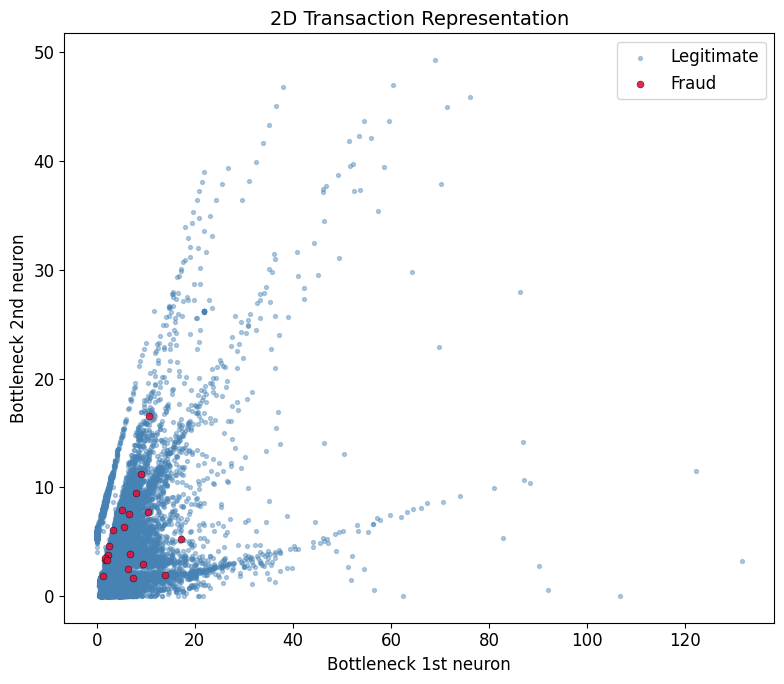

In [16]:
class Autoencoder2DViz(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 2), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 14), nn.ReLU(),
            nn.Linear(14, 20), nn.ReLU(),
            nn.Linear(20, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction

viz_model = Autoencoder2DViz(input_dim).to(device)
viz_criterion = nn.MSELoss()
viz_optimizer = torch.optim.Adam(viz_model.parameters())
viz_train_loader = DataLoader(TransactionDataset(X_fit), batch_size=256, shuffle=True)

viz_model.train()
for epoch in range(30):
    for batch in viz_train_loader:
        batch = batch.to(device)
        viz_optimizer.zero_grad()
        reconstruction = viz_model(batch)
        loss = viz_criterion(reconstruction, batch)
        loss.backward()
        viz_optimizer.step()

viz_model.eval()
with torch.no_grad():
    X_val_tensor = torch.from_numpy(X_val).to(device)
    X_val_2d = viz_model.encoder(X_val_tensor).cpu().numpy()

plt.figure(figsize=(8, 7))
plt.scatter(X_val_2d[y_val == 0, 0], X_val_2d[y_val == 0, 1],
            c='steelblue', s=8, alpha=0.4, label='Legitimate')
plt.scatter(X_val_2d[y_val == 1, 0], X_val_2d[y_val == 1, 1],
            c='crimson', s=25, alpha=0.9, label='Fraud', edgecolors='k', linewidths=0.3)
plt.xlabel('Bottleneck 1st neuron')
plt.ylabel('Bottleneck 2nd neuron')
plt.title('2D Transaction Representation')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Spremanje modela

In [17]:
torch.save(model.state_dict(), 'autoencoder_pytorch_model.pt')
joblib.dump(threshold, 'autoencoder_pytorch_threshold.pkl')
print("Model saved.")
print(f"Threshold: {threshold:.4f}")

Model saved.
Threshold: 2.0889
